<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/ExamPrep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

In [2]:
import os

from IPython.display import Image
from google.colab import userdata
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command, Send
from langchain_core.prompts import PromptTemplate
from typing import Annotated, Dict, List, Literal, Optional, TypedDict
from pydantic import BaseModel

os.environ["LANGSMITH_TRACING"]="true"
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_PROJECT"] = "AlgResearch"

openai_api_key = userdata.get('OPENAI_API_KEY')
openrouter_api_key = userdata.get('OPENROUTER_API_KEY')

In [3]:
def merge_dicts(a: Dict, b: Dict) -> Dict:
    return { **a, **b }

class Algorithm(BaseModel):
    name: str
    description: str
    time_complexity: str
    memory_complexity: str

class AlgorithmResearchResponse(BaseModel):
    algorithms: List[Algorithm]


class CodeGenerationResponse(BaseModel):
    code: str


class HumanFeedback(TypedDict):
    approved: bool
    comment: Optional[str]


class SystemState(TypedDict):
    problem_description: str

    # research should propose algorithm:
    algorithms: List[Algorithm]

    # TODO: Maybe we need to store the "Design interface" conversation history.
    interface_messages: List[BaseMessage] # Annotated add_messages {"interface_messages": [new...]}
    interface_feedback: HumanFeedback
    interface: str
    tests: str
    implementations:Annotated[Dict[str, str], merge_dicts] # key: name of alg, value: main implementation

In [4]:
research_agent = create_agent(
    model = ChatOpenAI(model = "gpt-5.4-mini", api_key = openai_api_key, reasoning_effort = "low"),
    tools = [{"type": "web_search"}],
    system_prompt = (
        "You are a senior algorithms researcher. Given a problem, use web search to consult "
        "authoritative references (textbooks, competitive-programming resources, academic notes) "
        "and then produce a thorough survey of solution approaches.\n\n"
        "Hard requirements:\n"
        "- Propose AT LEAST three meaningfully different algorithms - different paradigms, "
        "  data structures, or complexity profiles. Variants of the same idea do not count.\n"
        "- For each algorithm provide a detailed natural-language description of how it works.\n"
        "- Do NOT include code. Do NOT include pseudo-code. Prose only.\n"
        "- Discuss intuition, main steps, data structures, preconditions, and trade-offs.\n"
        "- State time and space complexity with a one-line justification."
    ),
    response_format = AlgorithmResearchResponse
)


architect_agent = create_agent(
    model= ChatOpenAI(model = "inception/mercury-2.5", api_key = openrouter_api_key, base_url = "https://openrouter.ai/api/v1"),
    tools = [], # TODO: Compile/Validate tool
    system_prompt = (
        "You are a senior C# API designer. Produce a single C# interface that every researched "
        "algorithm could implement The interface must be:\n"
        "- Minimal but sufficient for all approaches.\n"
        "- Easily testable: deterministic, side-effect free, value-based inputs and outputs, no hidden global state, no I/O.\n"
        "- Use immutable types or simple value types for inputs and outputs where possible.\n"
        "- Use modern C# (file-scoped namespace, nullable enabled).\n"
        "- Namespace: AlgorithmResearch.Contracts.\n"
        "Return the full file contents in C#."
    ),
    response_format = CodeGenerationResponse
)

qa_agent = create_agent(
    model = ChatOpenAI(model = "deepseek/deepseek-v4.1-flash", api_key = openrouter_api_key, base_url = "https://openrouter.ai/api/v1"),
    tools = [],
    system_prompt = (
        "You are a senior test engineer. Produce a thorough xUnit test suite that targets the "
        "given interface. Requirements:\n"
        "- AT LEAST 5 test cases.\n"
        "- Strong focus on edge cases: empty inputs, single-element inputs, duplicates, "
        " extreme values, ordering boundaries, and any algorithm-specific corner cases implied "
        " by the researched approaches.\n"
        "- Tests must be implementation-agnostic - runnable against any class implementing the "
        " interface. Use an abstract base test class exposing a factory method "
        " (protected abstract<Interface> CreateSubject()), any concrete subclasses are expected "
        " to be added per implementation later. Alternatively use [Theory] with [ClassData] "
        " yielding implementation instances.\n"
        "- Namespace: AlgorithmResearch.Tests. Reference AlgorithmResearch.Contracts.\n"
        "Return the full file contents in C#."
    ),
    response_format = CodeGenerationResponse
)

dev_agent = create_agent(
    model = ChatOpenAI(model = "gpt-5.6-luna", api_key = openai_api_key, reasoning_effort="none"),
    tools = [],
    system_prompt = (
        "You are a senior C# engineer. Implement the assigned algorithm as a class that "
        "implements the given interface.\n\n"
        "Requirements:\n"
        "- Faithful to the algorithm description provided - do not silently switch to a different approaches.\n"
        "- Production quality: clear naming, no TODOs, no placeholders, no Console output.\n"
        "- Modern C# with file-scoped namespace AlgorithmResearch.Implementations and nullable enabled.\n"
        "- Add 'using AlgorithmResearch.Contracts;' as needed.\n"
        "- The class must satisfy the test contracts - same shape and semantics as the interface specifies.\n"
        "- A short XML doc comment on the class is welcome; otherwise keep comments minimal.\n"
        "Return the full file contents in C#."
    ),
    response_format = CodeGenerationResponse
)

In [6]:
def format_algorithms(algorithms: List[Algorithm]) -> str:
    return "\n=========\n".join(f"Algorithm {idx + 1}: {alg.name}\n{alg.description}" for idx, alg in enumerate(algorithms))

In [7]:
def research(state: SystemState):
    problem_description = state["problem_description"]

    # agent
    proposed_algorithms = research_agent.invoke(
        input = {
            "messages": [HumanMessage(content=f"Problem Description:\n{problem_description}")]
        }
    )

    return { "algorithms": proposed_algorithms['structured_response'].algorithms }

def design_interface(state: SystemState):
    problem_description = state["problem_description"]
    algorithms = state['algorithms']

    history = state.get('interface_messages', [])

    if len(history) == 0:
      # да се обърнем към агент - на който да кажем описанието на проблема, това са алгоритмите - като агент да предостави c# решения на алгоритмите
      proposed_interface = architect_agent.invoke(
          input = {
              "messages": [
                    # Fill in previous messages.
                    *history,
                    HumanMessage(content=f"Problem Description:\n{problem_description}\n\n{format_algorithms(algorithms)}")
                  ]
          }
      )
    else:
        interface = state.get('interface', '')
        decision = interrupt(f"This is the proposed interface: {interface}\n\nDo you like it?")

        if decision['approved']:
            return { "interface_feedback": decision }

        proposed_interface = architect_agent.invoke(
          input = {
              "messages": [
                    # Fill in previous messages.
                    *history,
                    HumanMessage(content=f"The user rejected the proposed interface with the following comment:\n{decision['comment']}")
                  ]
          }
      )

    return {
        "interface": proposed_interface['structured_response'].code,
        "interface_messages": proposed_interface['messages']
    }

class AutomatedTestingTask(TypedDict):
    problem_description: str
    interface: str

def qa(state: AutomatedTestingTask):
    problem_description = state["problem_description"]
    interface = state['interface']

    # agent
    proposed_tests = qa_agent.invoke(
        input = {
            "messages": [HumanMessage(content=f"Problem Description:\n{problem_description}\n\nInterface:\n{interface}")]
        }
    )

    return {"tests": proposed_tests['structured_response'].code}

class ImplementationTask(TypedDict):
    problem_description: str
    interface: str
    algorithm: Algorithm

def dev(state: ImplementationTask):
    problem_description = state["problem_description"]
    interface = state["interface"]
    algorithm = state["algorithm"]

    proposed_implementation = dev_agent.invoke(
        input={
            "messages": [
                HumanMessage(
                    content=f"""
                            Problem Description:
                            {problem_description}

                            Algorithm:
                            {algorithm.name}

                            Description:
                            {algorithm.description}

                            Expected Complexity:
                            - Time: {algorithm.time_complexity}
                            - Memory: {algorithm.memory_complexity}

                            Interface:
                            {interface}
                            """.strip()
                )
            ]
        }
    )

    return {
        "implementations": {
            algorithm.name: proposed_implementation["structured_response"].code
        }
    }

def delegate_tasks(state: SystemState):
    feedback = state.get('interface_feedback')
    if feedback is None or not feedback['approved']:
        return "Design interface"

    tasks = [Send("QA",{"problem_description": state['problem_description'], "interface": state['interface'] })]
    for alg in state['algorithms']:
        tasks.append(Send("Dev", { "problem_description": state['problem_description'], "interface": state['interface'], "algorithm": alg }))

    return tasks

In [8]:
checkpointer = InMemorySaver()

In [9]:
graph_builder = StateGraph(SystemState)
graph_builder.add_node("Research", research);
graph_builder.add_node("Design interface", design_interface);
graph_builder.add_node("QA", qa);
graph_builder.add_node("Dev", dev);

graph_builder.add_edge(START, "Research")
graph_builder.add_edge("Research", "Design interface")

graph_builder.add_conditional_edges("Design interface", delegate_tasks, ["Design interface", "QA", "Dev"])

graph_builder.add_edge("QA", END)
graph_builder.add_edge("Dev", END)

graph = graph_builder.compile(checkpointer = checkpointer, debug = True)

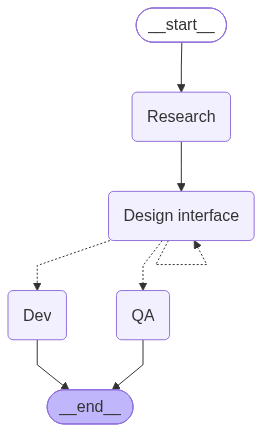

In [10]:
display(Image(data=graph.get_graph().draw_mermaid_png(), format = "png"))

In [11]:
thread1_config = {"configurable": {"thread_id": "thread1"}}

graph.invoke(
    input = {
        "problem_description": "I have a large binary search three. How can I find the nearest common ancestor for two nodes?"
    },
    config = thread1_config
)

[values] {'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?', 'implementations': {}}
[updates] {'Research': {'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each

{'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?',
 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a balanced 

In [12]:
graph.invoke(
    input = Command(resume = {'approved': False, "comment": "The tree node must have references towards its left and right child - this is a BST (binary search tree) that the algorithm uses." }),
    config = thread1_config
)

[values] {'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?', 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a b

{'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?',
 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a balanced 

In [13]:
graph.invoke(
    input = Command(resume = {'approved': False, "comment": "Rename the `TreeNode` and the `Key` property must be called `Value`." }),
    config = thread1_config
)

[values] {'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?', 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a b

{'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?',
 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a balanced 

In [14]:
graph.invoke(
    input = Command(resume = {'approved': True}),
    config = thread1_config
)

[values] {'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?', 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a b

{'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?',
 'algorithms': [Algorithm(name='BST split-point descent from the root', description='Use the binary-search-tree ordering to walk downward from the root until the search paths to the two targets diverge. If both target keys are smaller than the current node, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where one target is on the left side and the other is on the right side, or where the current node matches one of the targets, is the LCA. This is the standard BST-specific shortcut: the BST order lets you avoid exploring both subtrees and stop at the split point. ([davidespataro.dev](https://www.davidespataro.dev/chapters/lowest-common-ancestor-bst/?utm_source=openai))', time_complexity='O(h), where h is the tree height; each step moves one level down the tree, and in a balanced 